# IMPLEMENT VISION TRANSFORMER FOR IMAGE CLASSIFICATION

## STEP 1: Import necessary libraries

### 1.1. Clone repository

In [1]:
import os
import shutil

# Remove existing folder if it exists
if os.path.exists('DL_self_practice'):
    shutil.rmtree('DL_self_practice')

# Clone repository
!git clone https://github.com/ArrayPowerPlay/DL_self_practice.git

Cloning into 'DL_self_practice'...


### 1.2. Import libraries

In [8]:
import os 
import torch
from utils import spy

### 1.3. Check if GPU is available

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


## STEP 2: Train ViT model on FashionMNIST dataset

### 2.1. Dataset Introduction

Fashion MNIST is an MNIST-like dataset of 70,000 28x28 grayscale fashion image, associated with a label from 10 classes
- Training set: 60,000 examples
- Test set: 10,000 examples

### 2.2. Initialize hyperparameters and ViT model

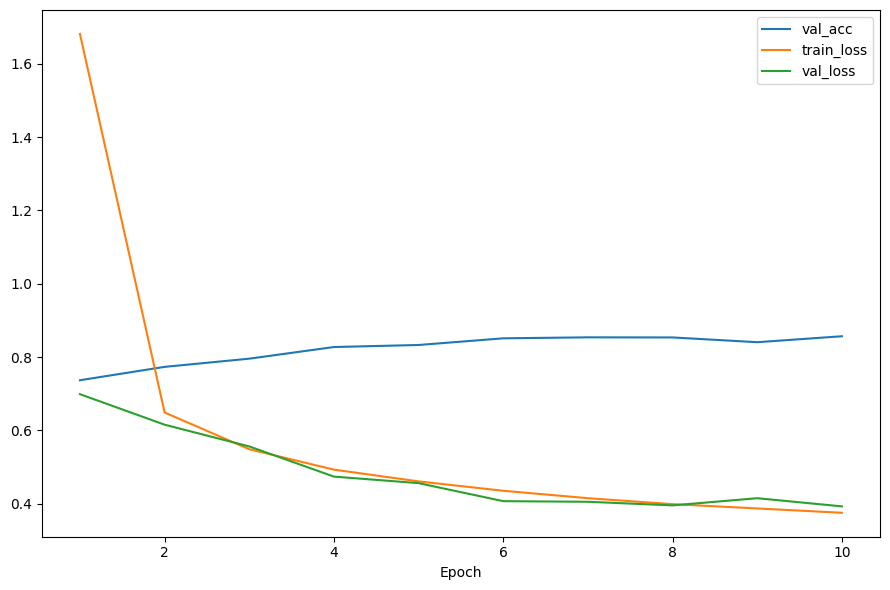

In [4]:
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
model = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = spy.Trainer(max_epochs=10)
data = spy.FashionMNIST(batch_size=128, resize=(img_size, img_size))
trainer.fit(model, data)

### 2.3. Show metrics of the last epoch

Show training loss, validation loss and validation accuracy

In [5]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])
print(model.board['val_acc'][-1])

0.37548307407258164
0.3929723836953127
0.8568037974683544


### 2.4. Show predictions of our model

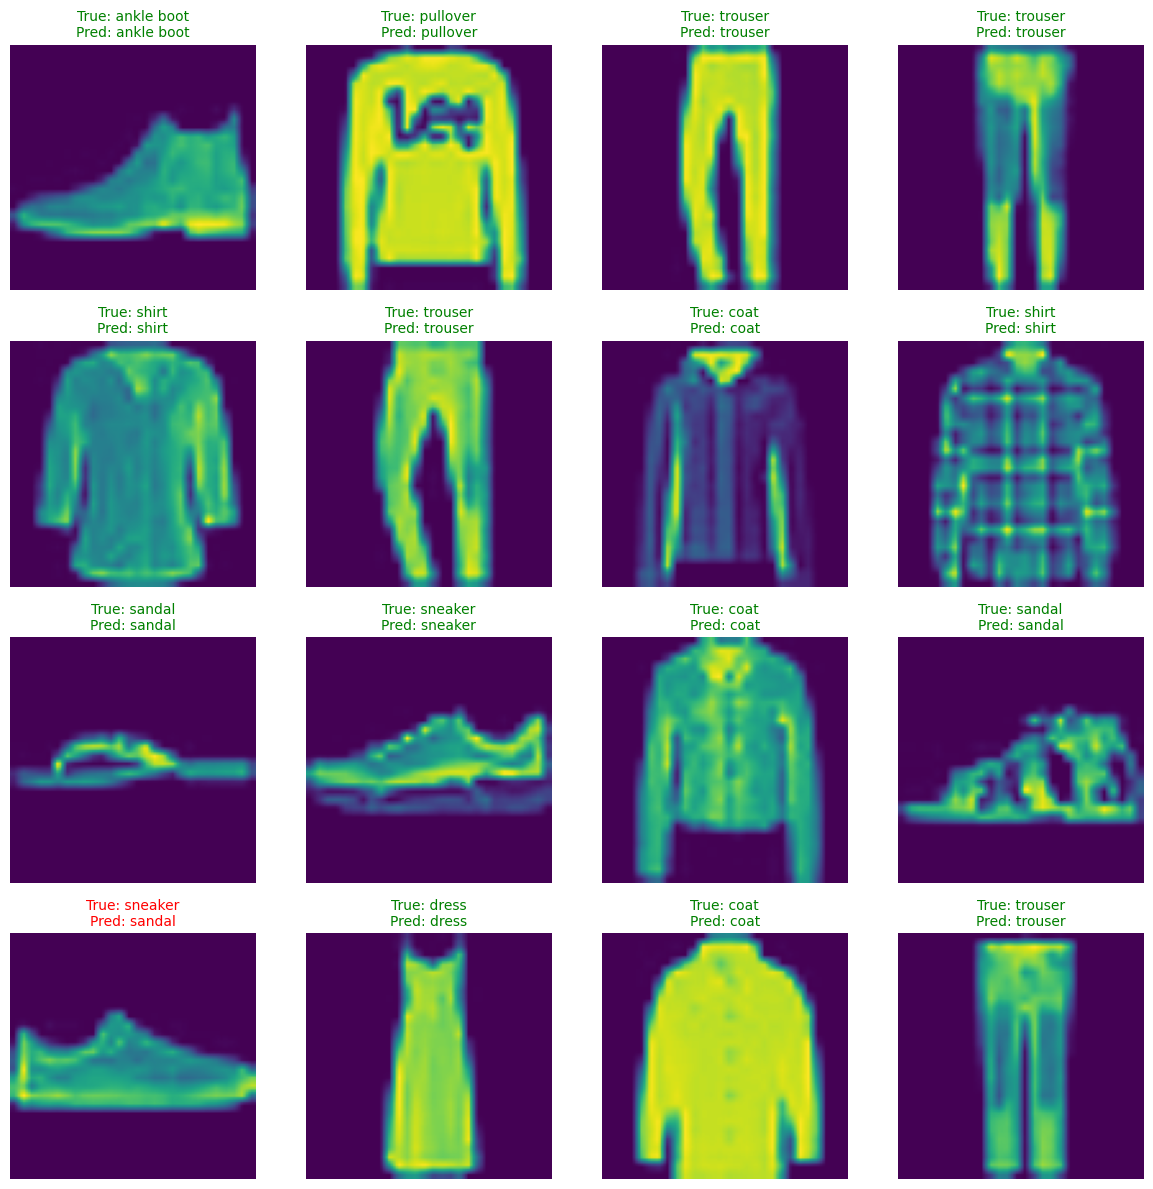

In [6]:
spy.visualize_prediction(model, data, 16, trainer, save_path='fashion_mnist_predictions.png')

### 2.5. Save checkpoints

In [7]:
torch.save({
    "model": model.state_dict(),
    "board": model.board, 
    "lr": model.lr,
}, "/kaggle/working/ViTfashion_MNIST_checkpoint.pt")

## STEP 3: Train ViT model on CIFAR-10 dataset

### 3.1. Dataset Introduction

The CIFAR-10 dataset consists of 60,000 32x32 colour image in 10 classes, with 6000 per classes
- Training images: 50,000 examples
- Testing images: 10,000 examples

### 3.2. Change hyperparameters to obtain good performance with CIFAR-10

In [8]:
img_size, patch_size = 96, 8
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 8
emb_dropout, blk_dropout, lr = 0.1, 0.1, 3e-4

### 3.3. Train model and show results

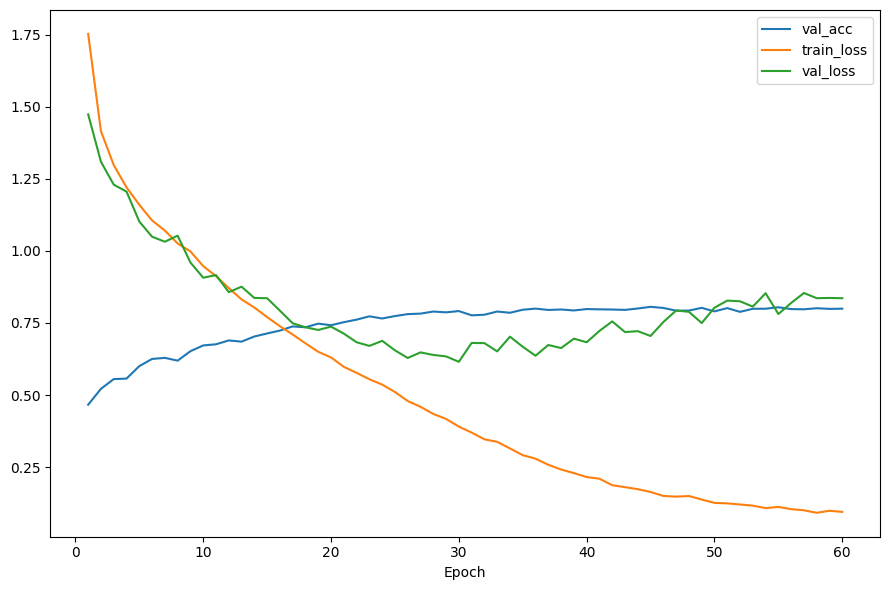

In [9]:
model_CIFAR10 = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr, optimizer_type='adamw', weight_decay=5e-2)
trainer_CIFAR10 = spy.Trainer(max_epochs=60)
data_CIFAR10 = spy.CIFAR10(batch_size=128, resize=(img_size, img_size))
trainer_CIFAR10.fit(model_CIFAR10, data_CIFAR10)

### 3.3. Show 3 metrics of the last epoch

Show training loss, validation loss and validation accuracy

In [10]:
print(model_CIFAR10.board['train_loss'][-1])
print(model_CIFAR10.board['val_loss'][-1])
print(model_CIFAR10.board['val_acc'][-1])

0.09423872765125063
0.8360169152670269
0.7997428797468354


### 3.4. Show predictions of our model

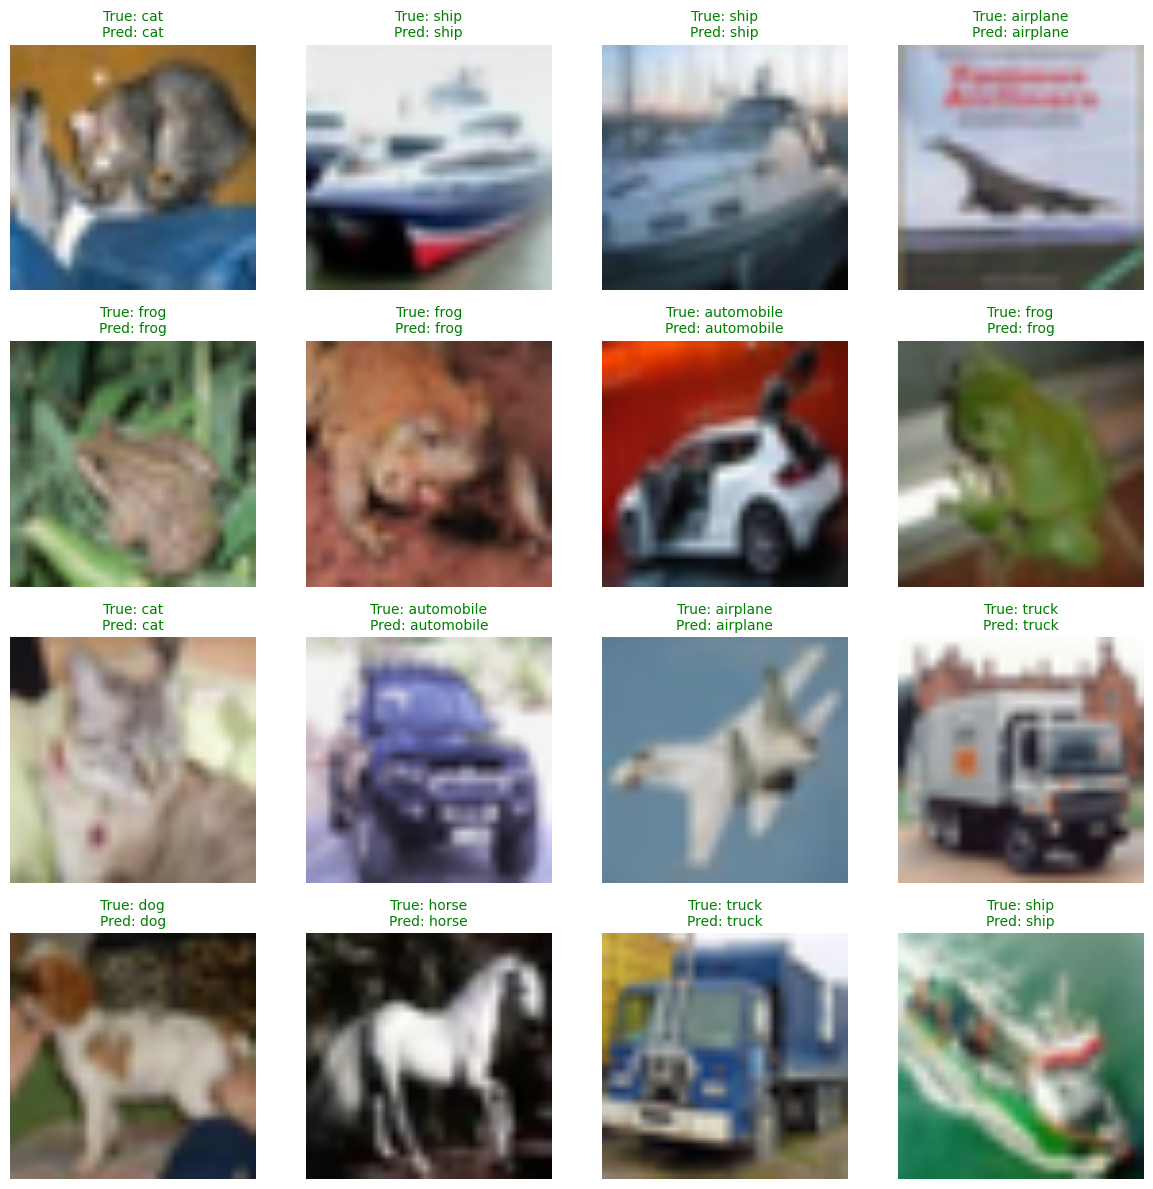

In [11]:
spy.visualize_prediction(model_CIFAR10, data_CIFAR10, 16, trainer_CIFAR10, save_path='cifar10_predictions.png')

### 3.5. Save checkpoints

In [12]:
torch.save({
    "model": model_CIFAR10.state_dict(),
    "board": model_CIFAR10.board, 
    "lr": model_CIFAR10.lr,
}, "/kaggle/working/ViTCIFAR10_checkpoint.pt")